# Test Fox (`fox.ckpt`)

Evaluates the released model on the 100 simulated test datasets in `test_data/Datasets/` (made with the current
simulator, so without lost-gene leaves), pre-encoded in `test_data/fox_data/`
(`python training/pre_encoder.py --src test_data/Datasets --dst test_data/fox_data`). Then: comparison with
AmoCoala, error vs tree size, the *Heliconius* real-data test, robustness to alignment length, row-order
invariance, Jukes-Cantor saturation, and the cockroach / *Blattabacterium* real-data test.

The previous model and its notebook are in `old/`.

In [22]:
import sys, os

import torch
import torch.nn.functional as F
import pandas as pd

from fox import load_model

CKPT_PATH = "fox.ckpt"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = load_model(CKPT_PATH, str(device))   # reads the architecture from the checkpoint
ckpt = torch.load(CKPT_PATH, map_location="cpu", weights_only=False)
print(f"Model loaded: epoch {ckpt.get('epoch', -1) + 1}, val loss {ckpt.get('val_loss', float('nan')):.6f}, "
      f"{sum(p.numel() for p in model.parameters()):,} params")

Model loaded: epoch 18, val loss 0.004172, 21,454,349 params


In [23]:
# ── Encoding utilities: the same functions training uses (fox/encoding.py) ─────
import re
from fox.encoding import (AMINO_ACIDS, AA_TO_INDEX, UNK_ID, PAD_ID, MAX_SEQ_LEN, JC_MAX_P,
                          encode_sequence, jukes_cantor_dist)   # 20-state protein Jukes-Cantor

def load_pt(path):
    s = torch.load(path, map_location="cpu", weights_only=False)
    if "host_msa" in s:
        return s["host_msa"], s["para_msa"], s["host_dist"], s["para_dist"], s["mappings"], s.get("labels")
    host_msas = s["host_msas"]
    para_msas = s["parasite_msas"]
    h_idx = {n: i for i, n in enumerate(host_msas)}
    p_idx = {n: i for i, n in enumerate(para_msas)}
    host_tok = torch.stack([encode_sequence(seq) for seq in host_msas.values()])
    para_tok = torch.stack([encode_sequence(seq) for seq in para_msas.values()])
    raw_mappings = s["mappings"]
    if raw_mappings and isinstance(raw_mappings[0], (tuple, list)) and isinstance(raw_mappings[0][0], str):
        mappings = [(h_idx[h], p_idx[p]) for p, h in raw_mappings if p in p_idx and h in h_idx]
    else:
        mappings = raw_mappings
    labels = s.get("event_frequencies") if s.get("event_frequencies") is not None else s.get("labels")
    return host_tok, para_tok, jukes_cantor_dist(host_tok), jukes_cantor_dist(para_tok), mappings, labels

_INDEX_TO_AA = {i: aa for aa, i in AA_TO_INDEX.items()}

def _decode(tok):
    return "".join(_INDEX_TO_AA.get(int(t), "X") for t in tok if int(t) != PAD_ID)

def load_as_strings(path):
    """A .pt as {host_msas, parasite_msas: {name: sequence}, mappings: [(parasite, host)], event_frequencies}.

    Pre-encoded files only store tokens: they are decoded back to sequences, with leaves named H<i> / P<j>
    after their row, so the sections below can truncate or reorder sequences by name."""
    s = torch.load(path, map_location="cpu", weights_only=False)
    if "host_msas" in s:
        return s
    host = {f"H{i}": _decode(t) for i, t in enumerate(s["host_msa"])}
    para = {f"P{j}": _decode(t) for j, t in enumerate(s["para_msa"])}
    return {"host_msas": host, "parasite_msas": para,
            "mappings": [(f"P{p}", f"H{h}") for h, p in s["mappings"]],
            "event_frequencies": s["labels"]}

_FREQ_KEYS = {"Speciation_freq": "Speciation", "HGT_freq": "HGT",
              "Loss_freq": "Loss", "Duplication_freq": "Duplication", "Sim_time": "Sim_time"}

def parse_tgl(path):
    result = dict(host_tree=None, para_tree=None,
                  host_msa={}, para_msa={},
                  distribution=[], event_freqs={})
    section, in_aln = None, False
    with open(path) as f:
        for line in f:
            s = line.strip()
            if s.startswith("BEGIN HOST;"):
                section, in_aln = "HOST", False; continue
            elif s.startswith("BEGIN PARASITE;"):
                section, in_aln = "PARA", False; continue
            elif s.startswith("BEGIN DISTRIBUTION;"):
                section = "DIST"; continue
            elif s in ("ENDBLOCK;", "END;"):
                section, in_aln = None, False; continue
            if section in ("HOST", "PARA"):
                m = re.match(r"TREE \* \S+ = (.+)", s)
                if m:
                    key = "host_tree" if section == "HOST" else "para_tree"
                    result[key] = m.group(1).rstrip(";"); continue
                if s.startswith("ALIGNMENT"):
                    in_aln = True; continue
                if in_aln and s == "'":
                    in_aln = False; continue
                if in_aln:
                    parts = s.split()
                    if len(parts) == 2:
                        d = result["host_msa"] if section == "HOST" else result["para_msa"]
                        d[parts[0]] = parts[1]
            elif section == "DIST":
                if ":" in s:
                    p, h = [x.strip() for x in s.split(":", 1)]
                    result["distribution"].append((p, h))
            else:
                for raw_key, std_key in _FREQ_KEYS.items():
                    if s.startswith(raw_key + ":"):
                        try:
                            result["event_freqs"][std_key] = float(s.split(":", 1)[1].strip())
                        except ValueError:
                            pass
    return result

def load_tgl(path):
    # Protein .tgl only (translate DNA first: python -m fox.translate). For old simulated .tgl files that
    # still contain lost-gene leaves, use fox.io.read_tgl(path, drop_lost=True) instead.
    d = parse_tgl(path)
    host_msas, para_msas = d["host_msa"], d["para_msa"]
    h_idx = {n: i for i, n in enumerate(host_msas)}
    p_idx = {n: i for i, n in enumerate(para_msas)}
    host_tok = torch.stack([encode_sequence(seq) for seq in host_msas.values()])
    para_tok = torch.stack([encode_sequence(seq) for seq in para_msas.values()])
    mappings = [(h_idx[h], p_idx[p])
                for p, h in d["distribution"] if p in p_idx and h in h_idx]
    labels = d["event_freqs"] or None
    return host_tok, para_tok, jukes_cantor_dist(host_tok), jukes_cantor_dist(para_tok), mappings, labels

print("Encoding utilities ready.")

Encoding utilities ready.


In [24]:
# ── Inference on a list of files ─────────────────────────────────────────────
EVENT_NAMES = ["Speciation", "HGT", "Loss", "Duplication"]
EVENT_LABELS = {"Speciation": "Cospeciation", "HGT": "Host switch", "Loss": "Loss", "Duplication": "Duplication"}
def disp(e): return EVENT_LABELS.get(e, e)  # plot label only; data keys stay "HGT"

def predict(paths):
    """
    paths    : list of .pt or .tgl file paths
    Returns  : pd.DataFrame with columns file, pred_*, [true_* if labels present]
    """
    rows = []
    with torch.no_grad():
        for path in paths:
            ext = os.path.splitext(path)[1].lower()
            if ext == ".pt":
                host_msa, para_msa, host_dist, para_dist, mappings, labels = load_pt(path)
            elif ext == ".tgl":
                host_msa, para_msa, host_dist, para_dist, mappings, labels = load_tgl(path)
            else:
                raise ValueError(f"Unknown extension {ext!r} — expected .pt or .tgl")

            out = model(
                host_msa.unsqueeze(0).to(device),
                para_msa.unsqueeze(0).to(device),
                [mappings],
                host_dist=host_dist.unsqueeze(0).to(device),
                para_dist=para_dist.unsqueeze(0).to(device),
            )  # [1, 4]

            pred = out.squeeze(0).cpu().tolist()
            row  = {"file": os.path.basename(path)}
            row.update({f"pred_{n}": v for n, v in zip(EVENT_NAMES, pred)})

            if isinstance(labels, dict):
                row.update({f"true_{n}": labels.get(n, float("nan")) for n in EVENT_NAMES})

            rows.append(row)

    return pd.DataFrame(rows)

print("predict() ready.")

predict() ready.


In [25]:
DATA_DIR = "test_data/fox_data"   

import glob
files = sorted(glob.glob(os.path.join(DATA_DIR, "*.pt")))

print(f"Found {len(files)} files")
df = predict(files)
df['speciation_diff'] = df['pred_Speciation'] -  df['true_Speciation']
df['HGT_diff'] = df['pred_HGT'] - df['true_HGT']
df['Loss_diff'] = df['pred_Loss'] - df['true_Loss']
df['Duplication_diff'] = df['pred_Duplication'] - df['true_Duplication']
print(df)

Found 100 files
          file  pred_Speciation  pred_HGT  pred_Loss  pred_Duplication  \
0   0000000.pt         0.698941  0.101343   0.065749          0.133968   
1   0000001.pt         0.562886  0.137003   0.190232          0.109878   
2   0000002.pt         0.757726  0.065328   0.094564          0.082381   
3   0000003.pt         0.707477  0.035202   0.035995          0.221326   
4   0000004.pt         0.824998  0.011463   0.036398          0.127141   
..         ...              ...       ...        ...               ...   
95  0000095.pt         0.532348  0.190822   0.087248          0.189581   
96  0000096.pt         0.736168  0.040430   0.097358          0.126044   
97  0000097.pt         0.695818  0.059636   0.112125          0.132421   
98  0000098.pt         0.688791  0.018778   0.113186          0.179244   
99  0000099.pt         0.663722  0.052137   0.064417          0.219724   

    true_Speciation  true_HGT  true_Loss  true_Duplication  speciation_diff  \
0            0.7

In [26]:
from scipy import stats
from sklearn.metrics import r2_score
import numpy as np

rows_metrics = []
for event in EVENT_NAMES:
    true = df[f"true_{event}"].values
    pred = df[f"pred_{event}"].values
    diff = pred - true
    mae  = np.abs(diff).mean()
    rmse = np.sqrt((diff**2).mean())
    r2   = r2_score(true, pred)
    bias = diff.mean()
    rows_metrics.append({
        "Event": event,
        "MAE": mae,
        'MRE': mae / np.mean(true) if np.mean(true) > 0 else 1e-6,
        "RMSE": rmse,
        "R²": r2,
        "Bias": bias,
    })

metrics_df = pd.DataFrame(rows_metrics).set_index("Event")
print(metrics_df.round(4))

                MAE     MRE    RMSE      R²    Bias
Event                                              
Speciation   0.0493  0.0794  0.0692  0.6557  0.0100
HGT          0.0166  0.2000  0.0208  0.8257 -0.0031
Loss         0.0336  0.3025  0.0448  0.4640 -0.0049
Duplication  0.0202  0.1093  0.0285  0.8247 -0.0020


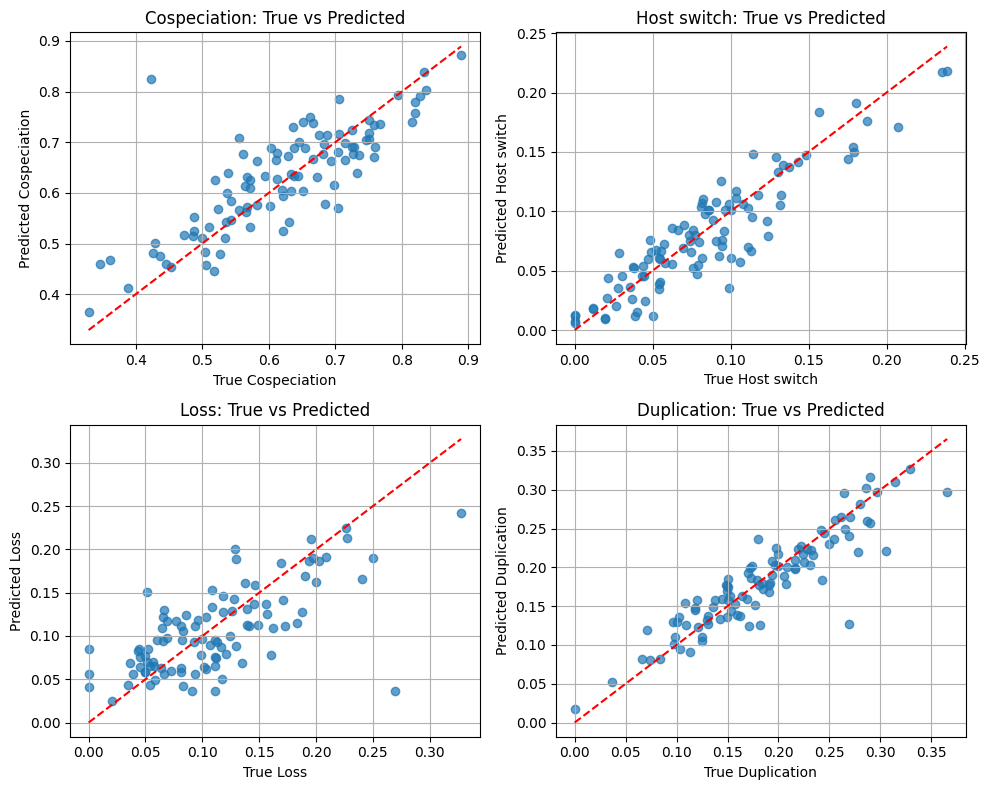

In [27]:
# plot true vs predicted
import matplotlib.pyplot as plt
import math

n = len(EVENT_NAMES)
cols = math.ceil(math.sqrt(n))
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten() if n > 1 else [axes]

for ax, event in zip(axes, EVENT_NAMES):
    true = df[f"true_{event}"]
    pred = df[f"pred_{event}"]
    ax.scatter(true, pred, alpha=0.7)
    ax.plot([true.min(), true.max()], [true.min(), true.max()], 'r--')
    ax.set_xlabel(f"True {disp(event)}")
    ax.set_ylabel(f"Predicted {disp(event)}")
    ax.set_title(f"{disp(event)}: True vs Predicted")
    ax.grid(True)

# hide unused axes
for ax in axes[n:]:
    ax.set_visible(False)

fig.tight_layout()
plt.savefig("test_data/fox_predictions.png", dpi=120, bbox_inches="tight")
plt.show()

## AmoCoala comparison on simulated test data

AmoCoala (https://github.com/sinaimeri/AmoCoala) is run on the true host and symbiont trees of each test
dataset and compared with Fox and with the simulator truth.

AmoCoala can take hours on some datasets. Each dataset gets at most `AC_TIMEOUT_MIN` minutes: past that the
Java process is killed and the dataset is written to `skipped.json` in the output folder, so later runs skip it
(`AC_RETRY_SKIPPED = True` tries them again). Finished datasets are never rerun, so the cells can be stopped
and restarted. Results for the 100 current test datasets go to `test_data/amocoala_data_100/`; the older
`test_data/amocoala_data/` belongs to the previous 40-dataset test set (`old/test_data/Datasets/`).

In [28]:
# ── AmoCoala helpers: .tgl -> AmoCoala NEXUS, run with a time limit, parse, compare ──
import glob, json, time, signal, subprocess
import numpy as np
from concurrent.futures import ThreadPoolExecutor, as_completed
from scipy import stats
from sklearn.metrics import r2_score

TGL_DIR          = "test_data/Datasets"
AMOCOALA_JAR     = os.environ.get("AMOCOALA_JAR", "/Users/gabriele/AmoCoala-main/AmoCoala.jar")
RUN_AMOCOALA     = True    # False: only read results already on disk
AC_TIMEOUT_MIN   = 30      # per dataset; slower datasets are killed and skipped
AC_RETRY_SKIPPED = False   # True: retry datasets that timed out before
AC_WORKERS       = max(1, (os.cpu_count() or 4) // 2)

_STRIP_BL  = re.compile(r":[0-9eE+\-.]*[0-9]")
_STRIP_INT = re.compile(r"\)[A-Za-z0-9_]+")

def _parse_newick_subtrees(nwk):
    """{node name: set of leaf names below it}."""
    nwk = _STRIP_BL.sub("", nwk.strip().rstrip(";"))
    subtree = {}
    def parse(s, pos):
        if s[pos] == "(":
            pos += 1; leaves = []
            while pos < len(s) and s[pos] != ")":
                child, pos = parse(s, pos)
                leaves.extend(child)
                if pos < len(s) and s[pos] == ",":
                    pos += 1
            pos += 1; start = pos
            while pos < len(s) and s[pos] not in ",)(":
                pos += 1
            name = s[start:pos].strip()
            if name:
                subtree[name] = set(leaves)
            return leaves, pos
        start = pos
        while pos < len(s) and s[pos] not in ",)":
            pos += 1
        name = s[start:pos].strip()
        if name:
            subtree[name] = {name}
        return [name], pos
    parse(nwk, 0)
    return subtree

def _collapse_unary(nwk):
    # AmoCoala's addVerticalSpread only handles binary internal nodes (Tree.java:1018):
    # unary internals crash it (NPE at line 1125), so collapse them.
    nwk = nwk.strip().rstrip(";"); pos = [0]
    def parse():
        if pos[0] < len(nwk) and nwk[pos[0]] == "(":
            pos[0] += 1; ch = [parse()]
            while pos[0] < len(nwk) and nwk[pos[0]] == ",":
                pos[0] += 1; ch.append(parse())
            pos[0] += 1; start = pos[0]
            while pos[0] < len(nwk) and nwk[pos[0]] not in ",()":
                pos[0] += 1
            return (nwk[start:pos[0]], ch)
        start = pos[0]
        while pos[0] < len(nwk) and nwk[pos[0]] not in ",()":
            pos[0] += 1
        return (nwk[start:pos[0]], None)
    def simplify(node):
        label, ch = node
        if ch is None: return node
        ch = [simplify(c) for c in ch]
        return ch[0] if len(ch) == 1 else (label, ch)
    def ser(node):
        label, ch = node
        return label if ch is None else "(" + ",".join(ser(c) for c in ch) + ")" + label
    return ser(simplify(parse()))

def _expand_dist(distribution, host_nwk):
    # A symbiont mapped to an internal host node is linked to every host leaf below it.
    st = _parse_newick_subtrees(host_nwk)
    leaves = {n for n, v in st.items() if v == {n}}
    out, seen = [], set()
    for p, h in distribution:
        for t in ([h] if h in leaves else sorted(st.get(h, []))):
            if (p, t) not in seen:
                out.append((p, t)); seen.add((p, t))
    return out

def write_amocoala_nexus(tgl_path, nex_path):
    d = parse_tgl(tgl_path)
    if d["host_tree"] is None or d["para_tree"] is None:
        return "could not parse trees"
    dist = _expand_dist(d["distribution"], d["host_tree"])
    host_nwk = _collapse_unary(_STRIP_INT.sub(")", _STRIP_BL.sub("", d["host_tree"])))
    para_nwk = _collapse_unary(_STRIP_INT.sub(")", _STRIP_BL.sub("", d["para_tree"])))
    host_leaves = {n for n, v in _parse_newick_subtrees(host_nwk).items() if v == {n}}
    para_leaves = {n for n, v in _parse_newick_subtrees(para_nwk).items() if v == {n}}
    dist = [(p, h) for p, h in dist if p in para_leaves and h in host_leaves]
    if len(dist) < 3:
        return f"too few valid leaf mappings: {len(dist)}"
    with open(nex_path, "w") as f:
        f.write("#NEXUS\n"
                f"BEGIN HOST;\n\tTREE HOST = {host_nwk};\nENDBLOCK;\n"
                f"BEGIN PARASITE;\n\tTREE PARASITE = {para_nwk};\nENDBLOCK;\n"
                "BEGIN DISTRIBUTION;\n\tRANGE\n\t\t" + ", ".join(f"{p} : {h}" for p, h in dist)
                + ";\nENDBLOCK;\n")
    return None

def _stem(tgl_path):
    return os.path.splitext(os.path.basename(tgl_path))[0]

def result_csv(out_dir, stem, n_rounds):
    return os.path.join(out_dir, stem, f"{stem}.nex.accep.round_{n_rounds}.csv")

def run_amocoala(tgl_path, out_dir, n_rounds, timeout_min):
    """Returns (status, seconds, message); status is ok / timeout / fail."""
    stem = _stem(tgl_path)
    os.makedirs(os.path.join(out_dir, stem), exist_ok=True)
    nex = os.path.join(out_dir, stem, f"{stem}.nex")
    err = write_amocoala_nexus(tgl_path, nex)
    if err:
        return "fail", 0.0, err
    t0 = time.time()
    # own process group, so a timeout kills Java and anything it started
    proc = subprocess.Popen(["java", "-jar", AMOCOALA_JAR, "-input", nex, "-N", "1000", "-M", "100",
                             "-R", str(n_rounds), "-t", ",".join(["0.1"] * n_rounds)],
                            stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True, start_new_session=True)
    try:
        out, errtxt = proc.communicate(timeout=timeout_min * 60)
    except subprocess.TimeoutExpired:
        os.killpg(proc.pid, signal.SIGKILL)
        proc.communicate()
        return "timeout", time.time() - t0, f"over {timeout_min} min"
    if os.path.exists(result_csv(out_dir, stem, n_rounds)):
        return "ok", time.time() - t0, ""
    return "fail", time.time() - t0, (errtxt or out)[-300:]

def run_amocoala_batch(tgls, out_dir, n_rounds, timeout_min=AC_TIMEOUT_MIN,
                       retry_skipped=AC_RETRY_SKIPPED, workers=AC_WORKERS):
    """Runs AmoCoala on every .tgl without a result yet; too-slow ones go to <out_dir>/skipped.json."""
    os.makedirs(out_dir, exist_ok=True)
    skip_file = os.path.join(out_dir, "skipped.json")
    skipped = json.load(open(skip_file)) if os.path.exists(skip_file) else {}
    done = [p for p in tgls if os.path.exists(result_csv(out_dir, _stem(p), n_rounds))]
    todo = [p for p in tgls if p not in done and (retry_skipped or os.path.basename(p) not in skipped)]
    print(f"{len(tgls)} datasets: {len(done)} done, {len(skipped)} skipped as too slow, "
          f"{len(todo) if RUN_AMOCOALA else 0} to run ({workers} at a time, {timeout_min} min limit each)")
    if RUN_AMOCOALA and todo:
        with ThreadPoolExecutor(max_workers=workers) as ex:
            futures = {ex.submit(run_amocoala, p, out_dir, n_rounds, timeout_min): p for p in todo}
            for fut in as_completed(futures):
                name = os.path.basename(futures[fut])
                status, secs, msg = fut.result()
                print(f"[{time.strftime('%H:%M:%S')}] {status:7s} {name} ({secs / 60:.1f} min) {msg}", flush=True)
                if status == "timeout":
                    skipped[name] = round(secs)
                elif status == "ok":
                    skipped.pop(name, None)
                json.dump(skipped, open(skip_file, "w"), indent=1)
    n_ok = sum(os.path.exists(result_csv(out_dir, _stem(p), n_rounds)) for p in tgls)
    print(f"AmoCoala results: {n_ok} / {len(tgls)}; skipped as too slow: {sorted(skipped)}")

def parse_ac_csv(path):
    # columns: cospeciation, duplication, host switch, loss (one row per accepted simulation)
    rows = [[float(x) for x in line.split("\t") if x.strip()] for line in open(path)]
    rows = [r for r in rows if len(r) >= 4]
    if not rows:
        return None
    cospec, dup, hsw, loss = np.array(rows)[:, :4].mean(0)
    total = (cospec + dup + hsw + loss) or 1.0
    return {"Speciation": cospec / total, "Duplication": dup / total, "HGT": hsw / total, "Loss": loss / total}

def amocoala_vs_fox(tgls, out_dir, n_rounds):
    """Truth, AmoCoala and Fox side by side (file = .tgl name), on datasets AmoCoala finished.
    Fox predictions come from df; .tgl and .pt are matched on their label values."""
    key = lambda vals: tuple(round(float(v), 4) for v in vals)
    fox_by_label = {key(r[f"true_{e}"] for e in EVENT_NAMES): r for _, r in df.iterrows()}
    rows = []
    for tgl in tgls:
        csv = result_csv(out_dir, _stem(tgl), n_rounds)
        if not os.path.exists(csv):
            continue
        ac = parse_ac_csv(csv)
        truth = parse_tgl(tgl)["event_freqs"]
        fox = fox_by_label.get(key(truth.get(e, 0.0) for e in EVENT_NAMES))
        if ac is None or fox is None:
            continue
        r = {"file": os.path.basename(tgl)}
        r.update({f"true_{e}": truth[e] for e in EVENT_NAMES})
        r.update({f"ac_{e}": ac[e] for e in EVENT_NAMES})
        r.update({f"pred_{e}": fox[f"pred_{e}"] for e in EVENT_NAMES})
        rows.append(r)
    out = pd.DataFrame(rows)
    print(f"Matched: {len(out)} datasets with both AmoCoala ({n_rounds} round(s)) and Fox")
    metrics = []
    for e in EVENT_NAMES:
        t = out[f"true_{e}"]
        for name, col in (("AmoCoala", "ac"), ("Fox", "pred")):
            p = out[f"{col}_{e}"]
            metrics.append({"Event": disp(e), "Method": name, "MAE": np.abs(p - t).mean(),
                            "RMSE": np.sqrt(((p - t) ** 2).mean()), "R²": r2_score(t, p),
                            "Pearson r": stats.pearsonr(t, p)[0], "Bias": (p - t).mean()})
    display(pd.DataFrame(metrics).set_index(["Event", "Method"]).round(4))
    return out

def plot_amocoala_vs_fox(d, png, title):
    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    for col, e in enumerate(EVENT_NAMES):
        t, a, p = d[f"true_{e}"], d[f"ac_{e}"], d[f"pred_{e}"]
        lo, hi = min(t.min(), a.min(), p.min()), max(t.max(), a.max(), p.max())
        for row, (vals, name, color, mk) in enumerate(((a, "AmoCoala", "C1", "s"), (p, "Fox", "C0", "o"))):
            ax = axes[row, col]
            ax.scatter(t, vals, alpha=0.7, s=50, color=color, marker=mk)   # marker per method: readable in B&W
            ax.plot([lo, hi], [lo, hi], "r--", lw=1)
            ax.set_title(f"{disp(e)}\n{name} r={stats.pearsonr(t, vals)[0]:.3f}")
            ax.set_xlabel("Simulator truth"); ax.set_ylabel(name); ax.grid(True)
    plt.suptitle(title, y=1.01)
    plt.tight_layout()
    plt.savefig(png, dpi=120, bbox_inches="tight")
    plt.show()

all_tgls = sorted(glob.glob(os.path.join(TGL_DIR, "*.tgl")),
                  key=lambda p: int(re.sub(r"\D", "", os.path.basename(p)) or 0))
print(f"AmoCoala helpers ready; {len(all_tgls)} test datasets in {TGL_DIR}")

AmoCoala helpers ready; 100 test datasets in test_data/Datasets


In [29]:
# ── AmoCoala, 1 round, all test datasets (resumable) ──
AC_DIR_1 = "test_data/amocoala_data_100"
run_amocoala_batch(all_tgls, AC_DIR_1, n_rounds=1)

100 datasets: 0 done, 0 skipped as too slow, 100 to run (7 at a time, 30 min limit each)
[19:08:18] ok      Dataset2.tgl (6.1 min) 
[19:09:03] ok      Dataset3.tgl (6.8 min) 
[19:10:17] ok      Dataset1.tgl (8.0 min) 
[19:13:46] ok      Dataset4.tgl (11.5 min) 
[19:18:11] ok      Dataset11.tgl (4.4 min) 
[19:20:49] ok      Dataset12.tgl (2.6 min) 
[19:23:19] ok      Dataset13.tgl (2.5 min) 
[19:26:06] ok      Dataset14.tgl (2.8 min) 
[19:29:13] ok      Dataset5.tgl (27.0 min) 
[19:30:01] ok      Dataset15.tgl (3.9 min) 
[19:32:14] timeout Dataset6.tgl (30.0 min) over 30 min
[19:32:14] timeout Dataset7.tgl (30.0 min) over 30 min
[19:38:18] timeout Dataset8.tgl (30.0 min) over 30 min
[19:39:03] timeout Dataset9.tgl (30.0 min) over 30 min
[19:40:17] timeout Dataset10.tgl (30.0 min) over 30 min


: 

: 

In [ ]:
df_cmp3_1 = amocoala_vs_fox(all_tgls, AC_DIR_1, n_rounds=1)

In [ ]:
plot_amocoala_vs_fox(df_cmp3_1, "test_data/amocoala_vs_fox.png",
                     "Top: AmoCoala vs truth  |  Bottom: Fox vs truth (1 AmoCoala round)")

In [ ]:
df_cmp3 = df_cmp3_1   # tree-size analysis uses the 1-round comparison on all datasets

## Performance vs. tree size (host & parasite)

Does accuracy degrade on larger trees? Scatter and binned MAE for Fox and AmoCoala across both host and parasite leaf count.

In [ ]:
# ── Performance vs. tree size (host & parasite) ───────────────────────────────
import re, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats

TGL_DIR = "test_data/Datasets"

leaf_rows = []
for tgl in sorted(__import__('glob').glob(f"{TGL_DIR}/*.tgl")):
    txt = open(tgl).read()
    h = re.search(r"Host_num_leaves: (\d+)", txt)
    s = re.search(r"Symbiont_num_leaves: (\d+)", txt)
    if h and s:
        leaf_rows.append({
            "file": __import__('os').path.basename(tgl),
            "host_leaves": int(h.group(1)),
            "sym_leaves":  int(s.group(1)),
        })

df_leaves = pd.DataFrame(leaf_rows)
df_sz = df_cmp3.merge(df_leaves, on="file", how="inner")
print(f"Datasets with leaf info: {len(df_sz)}")

for model_name, prefix in [("Fox", "pred"), ("AmoCoala", "ac")]:
    df_sz[f"mae_{model_name}"] = np.mean(
        [np.abs(df_sz[f"{prefix}_{e}"] - df_sz[f"true_{e}"]) for e in EVENT_NAMES], axis=0
    )

TREE_DIMS = [("host_leaves", "Host"), ("sym_leaves", "Parasite")]

# ── Figure 1: scatter MAE vs tree size (2 rows = host/para, 2 cols = model) ──
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
for row, (col_name, dim_label) in enumerate(TREE_DIMS):
    for ax, (model_name, color) in zip(axes[row], [("Fox", "C0"), ("AmoCoala", "C1")]):
        x = df_sz[col_name]
        y = df_sz[f"mae_{model_name}"]
        ax.scatter(x, y, alpha=0.75, s=60, color=color, edgecolors="k", linewidths=0.4)
        m, b, r, p, _ = stats.linregress(x, y)
        xl = np.array([x.min(), x.max()])
        ax.plot(xl, m * xl + b, "r--", lw=1.5, label=f"r={r:.2f}, p={p:.2f}")
        ax.set_xlabel(f"{dim_label} tree leaves")
        ax.set_ylabel("Mean MAE (4 events)")
        ax.set_title(f"{model_name} — {dim_label}")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
plt.suptitle("Error vs. tree size", y=1.01)
plt.tight_layout()
plt.savefig("test_data/error_vs_treesize_scatter.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Figure 2: binned MAE bar chart (side-by-side host / parasite) ─────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (col_name, dim_label) in zip(axes, TREE_DIMS):
    bins_cat = pd.qcut(df_sz[col_name], q=3, labels=["Small", "Medium", "Large"])
    bin_summary = []
    for b in bins_cat.cat.categories:
        sub = df_sz[bins_cat == b]
        lo, hi = sub[col_name].min(), sub[col_name].max()
        label = f"{b}\n(≤{hi})" if b == "Small" else (f"{b}\n(≥{lo})" if b == "Large" else f"{b}\n({lo}–{hi})")
        bin_summary.append({"Bin": label, "N": len(sub),
                             "Fox MAE": sub["mae_Fox"].mean(),
                             "AmoCoala MAE": sub["mae_AmoCoala"].mean()})
    df_bin = pd.DataFrame(bin_summary).set_index("Bin")
    print(f"\nBinned MAE — {dim_label} leaves:")
    print(df_bin.round(4))
    x_pos = np.arange(len(df_bin)); w = 0.35
    ax.bar(x_pos - w/2, df_bin["Fox MAE"],  w, label="Fox",  color="C0", alpha=0.85)
    ax.bar(x_pos + w/2, df_bin["AmoCoala MAE"], w, label="AmoCoala", color="C1", alpha=0.85,
           hatch="//", edgecolor="black", linewidth=0)  # stripes: readable in B&W
    ax.set_xticks(x_pos); ax.set_xticklabels(df_bin.index)
    ax.set_ylabel("Mean MAE (4 events)")
    ax.set_xlabel(f"{dim_label} tree size bin")
    ax.set_title(f"Error by {dim_label.lower()} tree size")
    ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("test_data/error_vs_treesize_binned.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Figure 3: per-event MAE vs tree size (2 rows = host/para, 4 cols = event) ─
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for row, (col_name, dim_label) in enumerate(TREE_DIMS):
    for ax, event in zip(axes[row], EVENT_NAMES):
        x = df_sz[col_name]
        # marker + line style per model: readable in B&W
        for model_key, color, marker, ls, lbl in [("pred", "C0", "o", "-",  "Fox"),
                                                  ("ac",   "C1", "^", "--", "AmoCoala")]:
            y = np.abs(df_sz[f"{model_key}_{event}"] - df_sz[f"true_{event}"])
            ax.scatter(x, y, alpha=0.6, s=45, color=color, marker=marker,
                       edgecolors="k", linewidths=0.4, label=lbl)
            m, b, r, p, _ = stats.linregress(x, y)
            xl = np.array([x.min(), x.max()])
            ax.plot(xl, m * xl + b, ls, color=color, lw=1.2)
        ax.set_title(f"{disp(event)} — {dim_label}")
        ax.set_xlabel(f"{dim_label} leaves")
        ax.set_ylabel("MAE")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
plt.suptitle("Per-event MAE vs. tree size  (top: host · bottom: parasite)", y=1.01)
plt.tight_layout()
plt.savefig("test_data/error_vs_treesize_per_event.png", dpi=120, bbox_inches="tight")
plt.show()

## AmoCoala on simulated data with more rounds

The same comparison with 3 AmoCoala rounds, on 5 test datasets (3 rounds take several times longer).
The 5 are spread over the datasets that finished the 1-round run, so they are known to be tractable.
Results go to `test_data/amocoala_small_100/`, with the same time limit and skip list.

In [ ]:
# ── AmoCoala, 3 rounds, 5 datasets (resumable) ──
AC_DIR_3 = "test_data/amocoala_small_100"
N_SMALL  = 5
finished = [p for p in all_tgls if os.path.exists(result_csv(AC_DIR_1, _stem(p), 1))] or all_tgls
small_tgls = [finished[round(i * (len(finished) - 1) / (N_SMALL - 1))] for i in range(N_SMALL)]
print("Datasets:", [os.path.basename(p) for p in small_tgls])
run_amocoala_batch(small_tgls, AC_DIR_3, n_rounds=3)

In [ ]:
df_cmp3_3 = amocoala_vs_fox(small_tgls, AC_DIR_3, n_rounds=3)

In [ ]:
plot_amocoala_vs_fox(df_cmp3_3, "test_data/amocoala_vs_fox_3rounds.png",
                     "Top: AmoCoala vs truth  |  Bottom: Fox vs truth (3 AmoCoala rounds)")

## Real-data test: Heliconius Müllerian mimicry

The published alignment is mitochondrial DNA (COI + COII). Fox reads amino acids, so the sequences are
translated first (invertebrate mitochondrial code, reading frame picked automatically):
`python -m fox.translate test_data/real_data/heliconius_mimicry.tgl test_data/real_data/heliconius_mimicry_aa.tgl --table 5`.
AmoCoala uses the trees in `heliconius.nex`, so it is unaffected.

At the protein level these sequences are almost identical (the host alignment has 1 variable column in the
250 Fox reads), far less divergent than the training data, so Fox has very little signal here.

In [ ]:
# ── 1. Show dataset contents ──────────────────────────────────────────────────
import pandas as pd

TGL_PATH = "test_data/real_data/heliconius_mimicry_aa.tgl"   # protein; original DNA: heliconius_mimicry.tgl
NEX_PATH = "test_data/real_data/heliconius.nex"
MAP_PATH = "test_data/real_data/heliconius_specimen_map.xlsx"

d = parse_tgl(TGL_PATH)
host_msa  = d["host_msa"]
para_msa  = d["para_msa"]
dist_pairs = d["distribution"]

# Specimen cross-reference
spec_map = pd.read_excel(MAP_PATH)
short_to_fig = dict(zip(spec_map["Short_name"], spec_map["Name_figure"]))

print("HOST (H. erato)")
for s in host_msa:
    print(f"  {s:12s}  {short_to_fig.get(s,'')}")

print()
print("PARASITE (H. melpomene) ")
for s in para_msa:
    print(f"  {s:12s}  {short_to_fig.get(s,'')}")

print()
print("Associations")
for p, h in dist_pairs:
    print(f"  {p:12s} : {h:12s}   {short_to_fig.get(p,''):25s} ↔ {short_to_fig.get(h,'')}")

In [ ]:
# ── 3a. Fox prediction ────────────────────────────────────────────────────
import torch

host_tok = torch.stack([encode_sequence(seq) for seq in host_msa.values()])
para_tok = torch.stack([encode_sequence(seq) for seq in para_msa.values()])
host_dist_t = jukes_cantor_dist(host_tok)
para_dist_t = jukes_cantor_dist(para_tok)
h_idx2 = {n: i for i, n in enumerate(host_msa)}
p_idx2 = {n: i for i, n in enumerate(para_msa)}
mappings = [(h_idx2[h], p_idx2[p]) for p, h in dist_pairs if p in p_idx2 and h in h_idx2]

with torch.no_grad():
    out = model(
        host_tok.unsqueeze(0).to(device),
        para_tok.unsqueeze(0).to(device),
        [mappings],
        host_dist=host_dist_t.unsqueeze(0).to(device),
        para_dist=para_dist_t.unsqueeze(0).to(device),
    )

fox_pred = dict(zip(EVENT_NAMES, out.squeeze(0).cpu().tolist()))
print("Fox prediction on Heliconius mimicry dataset:")
print(f"  {'Event':12s}  {'Prediction':>10s}")
print(f"  {'-'*25}")
for e, v in fox_pred.items():
    print(f"  {e:12s}  {v:10.4f}")
print(f"\n  Dominant signal: {max(fox_pred, key=fox_pred.get)} ({max(fox_pred.values()):.1%})")

In [ ]:
# ── 3b. AmoCoala on heliconius.nex ───────────────────────────────────────────
import subprocess, os

AMOCOALA_JAR = os.environ.get("AMOCOALA_JAR", "/Users/gabriele/AmoCoala-main/AmoCoala.jar")
NEX = "test_data/real_data/heliconius.nex"
R = 3
AC_CSV = NEX + f".accep.round_{R}.csv"

if not os.path.exists(AC_CSV):
    print("Running AmoCoala...")
    r = subprocess.run(
        f'java -jar {AMOCOALA_JAR} -input {NEX} -N 2000 -M 100 -R {R} -t 0.1,0.25,0.25',
        shell=True, capture_output=True, text=True, timeout=6000
    )
    print(r.stdout[-500:] if r.stdout else "")
    print(r.stderr[-500:] if r.stderr else "")
else:
    print(f"Reusing existing result: {AC_CSV}")

# Parse AmoCoala result (final round = posterior)
if os.path.exists(AC_CSV):
    rows = []
    with open(AC_CSV) as f:
        for line in f:
            vals = [float(x) for x in line.strip().split("\t") if x.strip()]
            if len(vals) >= 4:
                rows.append(vals)
    arr = np.array(rows)
    cospec, dup, hsw, loss = arr[:,0].mean(), arr[:,1].mean(), arr[:,2].mean(), arr[:,3].mean()
    total = cospec + dup + hsw + loss or 1.0
    ac_pred = {
        "Speciation":  cospec / total,
        "HGT":         hsw    / total,
        "Loss":        loss   / total,
        "Duplication": dup    / total,
    }
    print(f"\nAmoCoala result ({len(rows)} accepted solutions, round {R}):")
    print(f"  {'Event':12s}  {'Prediction':>10s}")
    print(f"  {'-'*25}")
    for e, v in ac_pred.items():
        print(f"  {e:12s}  {v:10.4f}")
    print(f"\n  Dominant signal: {max(ac_pred, key=ac_pred.get)} ({max(ac_pred.values()):.1%})")
else:
    ac_pred = None
    print("AmoCoala did not produce output.")

In [ ]:
# ── 4. Compare Fox vs AmoCoala on real Heliconius data ──
import matplotlib.pyplot as plt
import numpy as np

if ac_pred is None:
    print("AmoCoala result not available — skipping comparison.")
else:
    events = EVENT_NAMES
    x = np.arange(len(events))
    w = 0.35
    series = [
        ("Fox",      fox_pred, "C0", -w/2, None),
        ("AmoCoala", ac_pred,  "C1",  w/2, "//"),  # stripes: readable in B&W
    ]

    fig, ax = plt.subplots(figsize=(10, 5))
    for name, pred, color, off, hatch in series:
        bars = ax.bar(x + off, [pred[e] for e in events], w,
                      label=name, color=color, alpha=0.85,
                      hatch=hatch, edgecolor="black", linewidth=0)
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.005, f"{h:.3f}",
                    ha="center", va="bottom", fontsize=7)

    ax.set_xticks(x); ax.set_xticklabels([disp(e) for e in events])
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Estimated frequency")
    ax.set_title("Heliconius mimicry: Fox vs AmoCoala\n"
                 "(Hoyal Cuthill & Charleston 2012 — Figure 2 dataset)")
    ax.legend()
    ax.axhline(0.5, color="gray", lw=0.8, ls="--", alpha=0.5)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig("test_data/heliconius_fox_vs_amocoala.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved: test_data/heliconius_fox_vs_amocoala.png")

    # ── Summary table ──────────────────────────────────────────────────────────
    print("\nSummary:")
    print(f"  {'Event':12s}  {'Fox':>8s}  {'AmoCoala':>8s}")
    print(f"  {'-'*32}")
    for e in events:
        print(f"  {e:12s}  {fox_pred[e]:8.4f}  {ac_pred[e]:8.4f}")
    print()
    print("  Expected: tools should agree on high Speciation")
    print("  (parallel cospeciation = textbook case for this dataset)")

## Leaf-removal experiment: dropping Hmelp246

One symbiont specimen (*H. melpomene malleti*, `Hmelp246`, East Ecuador) is ~76% gaps
over the full alignment and 100% gaps within the first 250 columns Fox reads
(`MAX_SEQ_LEN = 250`), so it carries no phylogenetic signal. We drop it and re-run
**both** Fox and AmoCoala to see whether the cospeciation-dominated profile sharpens,
and whether the effect is specific to Fox's fixed input window or reflects the
specimen itself.

In [ ]:
# -- Leaf-removal: Fox WITHOUT the Hmelp246 <-> its host association pair --
DROP = "Hmelp246"
DROP_HOST = next(h for (p, h) in dist_pairs if p == DROP)   # = Herato75
print(f"Removing association pair: {DROP} <-> {DROP_HOST}")

para_msa_nl   = {k: v for k, v in para_msa.items() if k != DROP}
host_msa_nl   = {k: v for k, v in host_msa.items() if k != DROP_HOST}
dist_pairs_nl = [(p, h) for (p, h) in dist_pairs if p != DROP and h != DROP_HOST]

host_tok_nl = torch.stack([encode_sequence(seq) for seq in host_msa_nl.values()])
para_tok_nl = torch.stack([encode_sequence(seq) for seq in para_msa_nl.values()])
host_dist_nl = jukes_cantor_dist(host_tok_nl)
para_dist_nl = jukes_cantor_dist(para_tok_nl)
h_idx_nl = {n: i for i, n in enumerate(host_msa_nl)}
p_idx_nl = {n: i for i, n in enumerate(para_msa_nl)}
map_nl = [(h_idx_nl[h], p_idx_nl[p]) for p, h in dist_pairs_nl if p in p_idx_nl and h in h_idx_nl]

with torch.no_grad():
    out_nl = model(
        host_tok_nl.unsqueeze(0).to(device),
        para_tok_nl.unsqueeze(0).to(device),
        [map_nl],
        host_dist=host_dist_nl.unsqueeze(0).to(device),
        para_dist=para_dist_nl.unsqueeze(0).to(device),
    )
fox_pred_nl = dict(zip(EVENT_NAMES, out_nl.squeeze(0).cpu().tolist()))
print(f"Fox WITHOUT {DROP} (+ host {DROP_HOST}):")
for e, v in fox_pred_nl.items():
    print(f"  {e:12s}  {v:10.4f}")
print(f"\n  Dominant: {max(fox_pred_nl, key=fox_pred_nl.get)} "
      f"({max(fox_pred_nl.values()):.1%})")

In [ ]:
# -- Auto-build the pruned .nex for AmoCoala (no extra dependencies) --
# Removes the whole association pair: the parasite leaf Hmelp246 AND its host.
import re

SRC_NEX = "test_data/real_data/heliconius.nex"
NEX_NL  = "test_data/real_data/filtered/heliconius_no_Hmelp246.nex"
DROP    = "Hmelp246"

def _parse_newick(s):
    s = s.strip().rstrip(";"); pos = 0
    def parse():
        nonlocal pos
        if s[pos] == "(":
            pos += 1; kids = []
            while True:
                kids.append(parse())
                if s[pos] == ",": pos += 1
                elif s[pos] == ")": pos += 1; break
            return kids
        start = pos
        while pos < len(s) and s[pos] not in ",()": pos += 1
        return s[start:pos]
    return parse()

def _prune(node, drop):
    if isinstance(node, str):
        return None if node == drop else node
    kids = [k for k in (_prune(c, drop) for c in node) if k is not None]
    if not kids: return None
    if len(kids) == 1: return kids[0]        # collapse unary node
    return kids

def _to_newick(node):
    if isinstance(node, str): return node
    return "(" + ",".join(_to_newick(c) for c in node) + ")"

raw  = open(SRC_NEX).read()
host = re.search(r"TREE\s+HOST\s*=\s*(.+?);", raw, re.S).group(1).strip()
par  = re.search(r"TREE\s+PARASITE\s*=\s*(.+?);", raw, re.S).group(1).strip()
rng  = re.search(r"RANGE\s*(.+?);", raw, re.S).group(1)

pairs     = [p.strip() for p in rng.split(",") if p.strip()]
DROP_HOST = next(p.split(":")[1].strip() for p in pairs if p.split(":")[0].strip() == DROP)
print(f"Removing association pair: {DROP} <-> {DROP_HOST}")

par_pruned  = _to_newick(_prune(_parse_newick(par),  DROP))
host_pruned = _to_newick(_prune(_parse_newick(host), DROP_HOST))

pairs_nl = [p for p in pairs
            if p.split(":")[0].strip() != DROP and p.split(":")[1].strip() != DROP_HOST]
range_nl = ",\n\t\t".join(pairs_nl)

nex = (
    "#NEXUS\n"
    "BEGIN HOST;\n"
    f"\tTREE HOST = {host_pruned};\n"
    "ENDBLOCK;\n"
    "BEGIN PARASITE;\n"
    f"\tTREE PARASITE = {par_pruned};\n"
    "ENDBLOCK;\n"
    "BEGIN DISTRIBUTION;\n"
    f"\tRANGE\n\t\t{range_nl};\n"
    "ENDBLOCK;\n"
)
open(NEX_NL, "w").write(nex)
assert DROP not in nex and DROP_HOST not in nex, "a dropped taxon is still present!"
print(f"Wrote {NEX_NL}  ({len(pairs_nl)} associations; {DROP} and {DROP_HOST} removed)\n")
print(nex)

In [ ]:
# -- Leaf-removal: AmoCoala WITHOUT Hmelp246 --
AMOCOALA_JAR = os.environ.get("AMOCOALA_JAR", "/Users/gabriele/AmoCoala-main/AmoCoala.jar")
# The pruned .nex is created automatically by the previous cell; this one just
# runs AmoCoala on it and parses the result (same settings as the full run).
NEX_NL   = "test_data/real_data/filtered/heliconius_no_Hmelp246.nex"
R        = 3
AC_CSV_NL = NEX_NL + f".accep.round_{R}.csv"

ac_pred_nl = None
if os.path.exists(NEX_NL):
    if not os.path.exists(AC_CSV_NL):
        print("Running AmoCoala (no Hmelp246)...")
        r = subprocess.run(
            f'java -jar {AMOCOALA_JAR} -input {NEX_NL} -N 2000 -M 100 -R {R} -t 0.1,0.25,0.25',
            shell=True, capture_output=True, text=True, timeout=6000)
        print(r.stdout[-500:] if r.stdout else "")
        print(r.stderr[-300:] if r.stderr else "")
    if os.path.exists(AC_CSV_NL):
        rows = []
        with open(AC_CSV_NL) as f:
            for line in f:
                vals = [float(x) for x in line.strip().split("\t") if x.strip()]
                if len(vals) >= 4:
                    rows.append(vals)
        arr = np.array(rows)
        cospec, dup, hsw, loss = arr[:,0].mean(), arr[:,1].mean(), arr[:,2].mean(), arr[:,3].mean()
        tot = cospec + dup + hsw + loss or 1.0
        ac_pred_nl = {"Speciation": cospec/tot, "HGT": hsw/tot,
                      "Loss": loss/tot, "Duplication": dup/tot}
        print(f"AmoCoala WITHOUT Hmelp246 ({len(rows)} solutions):")
        for e, v in ac_pred_nl.items():
            print(f"  {e:12s}  {v:10.4f}")
else:
    print(f"Pruned .nex not found: {NEX_NL}\nCreate it, then re-run this cell.")

In [ ]:
# -- Leaf-removal comparison: Fox / AmoCoala, with vs without Hmelp246 --
def _row(name, p):
    if p is None:
        return f"  {name:24s}  " + "     n/a" * len(EVENT_NAMES)
    return f"  {name:24s}  " + "".join(f"{p[e]:8.4f}" for e in EVENT_NAMES)

print(f"  {'':24s}  " + "".join(f"{disp(e):>8s}" for e in EVENT_NAMES))
print("  " + "-" * 56)
print(_row("Fox (full)",            fox_pred))
print(_row("Fox (no Hmelp246)",     fox_pred_nl))
print(_row("AmoCoala (full)",       ac_pred))
print(_row("AmoCoala (no Hmelp246)", ac_pred_nl))

## Robustness to alignment length

Fox reads a fixed window of `MAX_SEQ_LEN = 250` columns (shorter alignments are
padded; longer ones are truncated). Here we probe how accuracy depends on the
number of informative columns: for each held-out test dataset we truncate every
sequence to `k` columns (k = 50, 100, 150, 200, 250), pad back to the 250 window,
re-run Fox, and score against the ground truth. This isolates the effect of
alignment length (same sites, fewer of them). Testing lengths **beyond** 250 would
require raising `MAX_SEQ_LEN` and retraining, since the window is fixed.

In [ ]:
# -- Length sweep: truncate test MSAs to k columns, re-score Fox --
import glob, numpy as np, pandas as pd

EVENT_NAMES = ["Speciation", "HGT", "Loss", "Duplication"]
LENS  = [50, 100, 150, 200, 250]
files = sorted(glob.glob(f"{DATA_DIR}/*.pt"))

def _pred_at_len(hm, pm, maps, k):
    ht = torch.stack([encode_sequence(s[:k]) for s in hm.values()])   # first k cols, pad to 250
    pt = torch.stack([encode_sequence(s[:k]) for s in pm.values()])
    with torch.no_grad():
        o = model(ht.unsqueeze(0).to(device), pt.unsqueeze(0).to(device), [maps],
                  host_dist=jukes_cantor_dist(ht).unsqueeze(0).to(device),
                  para_dist=jukes_cantor_dist(pt).unsqueeze(0).to(device))
    return o.squeeze(0).cpu().tolist()

sweep = {L: {"pred": [], "true": []} for L in LENS}
for i, f in enumerate(files):
    s = load_as_strings(f)
    hm, pm = s["host_msas"], s["parasite_msas"]
    hi = {n: j for j, n in enumerate(hm)}; pi = {n: j for j, n in enumerate(pm)}
    raw = s["mappings"]
    maps = ([(hi[h], pi[p]) for p, h in raw if p in pi and h in hi]
            if raw and isinstance(raw[0][0], str) else raw)
    true = [s["event_frequencies"][e] for e in EVENT_NAMES]
    for L in LENS:
        sweep[L]["pred"].append(_pred_at_len(hm, pm, maps, L))
        sweep[L]["true"].append(true)
    if (i + 1) % 20 == 0:
        print(f"  {i+1}/{len(files)} done")

rows = []
for L in LENS:
    P = np.array(sweep[L]["pred"]); T = np.array(sweep[L]["true"])
    mae = np.abs(P - T).mean(0)
    r2  = 1 - ((T - P) ** 2).sum(0) / ((T - T.mean(0)) ** 2).sum(0)
    for j, e in enumerate(EVENT_NAMES):
        rows.append({"length": L, "event": e, "MAE": mae[j], "R2": r2[j]})
sweep_df = pd.DataFrame(rows)

print("\nR^2 by alignment length:")
print(sweep_df.pivot(index="length", columns="event", values="R2").round(3))
print("\nMAE by alignment length:")
print(sweep_df.pivot(index="length", columns="event", values="MAE").round(4))

In [ ]:
# -- Plot MAE and R^2 vs alignment length --
import matplotlib.pyplot as plt

DISPLAY = {"Speciation": "Cospeciation", "HGT": "Host Switch",
           "Loss": "Loss", "Duplication": "Duplication"}

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
# marker + line style per event: readable in B&W
for e, mk, ls in zip(EVENT_NAMES, ["o", "^", "s", "D"], ["-", "--", ":", "-."]):
    sub = sweep_df[sweep_df.event == e].sort_values("length")
    ax[0].plot(sub.length, sub.MAE, marker=mk, ls=ls, label=DISPLAY[e])
    ax[1].plot(sub.length, sub.R2,  marker=mk, ls=ls, label=DISPLAY[e])
ax[0].set(xlabel="Alignment length (columns)", ylabel="MAE", title="MAE vs alignment length")
ax[1].set(xlabel="Alignment length (columns)", ylabel="$R^2$", title="$R^2$ vs alignment length")
ax[1].axhline(0, color="gray", lw=0.8, ls="--")
for a in ax:
    a.axvline(250, color="gray", lw=0.8, ls=":")   # trained window
    a.grid(alpha=0.3); a.legend()
plt.tight_layout()
plt.savefig("test_data/error_vs_seqlen.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: test_data/error_vs_seqlen.png")

## Permutation invariance of the MSA row order

A model that estimates cophylogenetic event frequencies should not care about the
*order* in which sequences are listed in the host and parasite MSAs - the same pair of
trees is being described either way. (A bug of exactly this kind was found in evoPF's
outer-product mean.)

The shuffling follows Luc's `shuffle_seqs` datasets in `core.py`
(`UnambiguousMergeOrderDataset` / `MultisizeUnambiguousMergeOrderDataset`): a seeded
`torch.Generator`, `perm = torch.randperm(len(ids))`, MSA rows permuted by `perm` and
the **id list permuted the same way**, with everything downstream rebuilt from the
reordered ids. Adapted here to Fox's paired input: host and parasite MSAs get
independent permutations, the stored distance matrices are permuted consistently
(`D[perm][:, perm]`), and the host/parasite associations are rebuilt **from the leaf
names**, not by index arithmetic - so a wrong permutation shows up as scrambled
associations instead of silently agreeing.

Run over **all** datasets in `DATA_DIR`. Predictions should be identical up to float32
round-off (~1e-7).

In [ ]:
# -- Shuffled dataset (mirrors Luc's `shuffle_seqs` datasets in core.py) --
import glob
import numpy as np
import pandas as pd
from torch.utils.data import Dataset

class ShuffledCophyloDataset(Dataset):
    """Fox .pt datasets, optionally with host/parasite leaf order shuffled.

    Same shuffling contract as core.py's UnambiguousMergeOrderDataset:
    seeded torch.Generator -> randperm over ids -> permute rows AND ids, then
    rebuild everything that references the leaves from the reordered ids.
    """

    def __init__(self, files: list[str], shuffle_seqs: bool = False,
                 seed: int = 123467890) -> None:
        super().__init__()
        self.files = files
        self.shuffle_seqs = shuffle_seqs
        self.rng = torch.Generator()
        self.rng.manual_seed(seed)

    def __len__(self) -> int:
        return len(self.files)

    def __getitem__(self, index):
        s = load_as_strings(self.files[index])
        host_msas, para_msas = s["host_msas"], s["parasite_msas"]
        host_ids, para_ids = list(host_msas), list(para_msas)
        host_dist, para_dist = s.get("host_dist"), s.get("para_dist")
        hperm = pperm = None

        if self.shuffle_seqs:
            hperm = torch.randperm(len(host_ids), generator=self.rng)
            pperm = torch.randperm(len(para_ids), generator=self.rng)
            host_ids = [host_ids[i] for i in hperm]
            para_ids = [para_ids[i] for i in pperm]
            if host_dist is not None:
                host_dist = host_dist[hperm][:, hperm]
            if para_dist is not None:
                para_dist = para_dist[pperm][:, pperm]

        host_tok = torch.stack([encode_sequence(host_msas[i]) for i in host_ids])
        para_tok = torch.stack([encode_sequence(para_msas[i]) for i in para_ids])
        if host_dist is None:
            host_dist = jukes_cantor_dist(host_tok)
        if para_dist is None:
            para_dist = jukes_cantor_dist(para_tok)

        # associations rebuilt from leaf NAMES against the (possibly reordered) ids
        h_idx = {n: i for i, n in enumerate(host_ids)}
        p_idx = {n: i for i, n in enumerate(para_ids)}
        raw = s["mappings"]
        if raw and isinstance(raw[0][0], str):
            maps = [(h_idx[h], p_idx[p]) for p, h in raw if p in p_idx and h in h_idx]
        elif self.shuffle_seqs:   # index-based mappings: remap through the permutation
            hi = {int(o): i for i, o in enumerate(hperm)}
            pi = {int(o): i for i, o in enumerate(pperm)}
            maps = [(hi[h], pi[p]) for h, p in raw]
        else:
            maps = list(raw)

        return {"file": os.path.basename(self.files[index]),
                "host_tok": host_tok, "para_tok": para_tok,
                "host_dist": host_dist, "para_dist": para_dist,
                "mappings": maps, "host_ids": host_ids, "para_ids": para_ids,
                "labels": s.get("event_frequencies") or s.get("labels")}

def fox_forward(host_tok, para_tok, host_dist, para_dist, maps):
    with torch.no_grad():
        o = model(host_tok.unsqueeze(0).to(device), para_tok.unsqueeze(0).to(device), [maps],
                  host_dist=host_dist.unsqueeze(0).to(device),
                  para_dist=para_dist.unsqueeze(0).to(device))
    return o.squeeze(0).cpu().numpy()

def predict_item(item):
    return fox_forward(item["host_tok"], item["para_tok"],
                       item["host_dist"], item["para_dist"], item["mappings"])

print("ShuffledCophyloDataset ready.")

In [ ]:
# -- Reference order vs N_PERM shuffled orders, over ALL datasets --
PERM_DATA_DIR = DATA_DIR          # test_data/fox_data
N_PERM        = 5                 # shuffled passes per dataset
SEED          = 123467890         # same default seed as core.py

perm_files = sorted(glob.glob(os.path.join(PERM_DATA_DIR, "*.pt")))   # all datasets

ds_ref = ShuffledCophyloDataset(perm_files, shuffle_seqs=False)
# one shuffled dataset per round; different seed each round -> different permutations
ds_shuf = [ShuffledCophyloDataset(perm_files, shuffle_seqs=True, seed=SEED + k)
           for k in range(N_PERM)]

perm_rows, n_identity = [], 0
for i in range(len(ds_ref)):
    ref = ds_ref[i]
    perm_rows.append({"file": ref["file"], "perm": 0,
                      **{e: v for e, v in zip(EVENT_NAMES, predict_item(ref))}})
    for k, ds in enumerate(ds_shuf, start=1):
        item = ds[i]
        n_identity += int(item["host_ids"] == ref["host_ids"]
                          and item["para_ids"] == ref["para_ids"])
        perm_rows.append({"file": ref["file"], "perm": k,
                          **{e: v for e, v in zip(EVENT_NAMES, predict_item(item))}})

df_perm = pd.DataFrame(perm_rows)
print(f"{len(perm_files)} datasets x {N_PERM} shuffles "
      f"({len(df_perm)} forward passes incl. reference)")
print(f"identity (no-op) shuffles: {n_identity}")
print("example reordering:")
print("  reference host ids:", ds_ref[0]["host_ids"][:8])
print("  shuffled  host ids:", ds_shuf[0][0]["host_ids"][:8])

In [ ]:
# -- Deviation of shuffled predictions from the reference ordering --
perm_base = df_perm[df_perm.perm == 0].set_index("file")[EVENT_NAMES]
df_dev    = df_perm[df_perm.perm > 0].copy()
for e in EVENT_NAMES:
    df_dev[f"dev_{e}"] = df_dev[e].values - perm_base.loc[df_dev.file, e].values

dev_cols = [f"dev_{e}" for e in EVENT_NAMES]
abs_dev  = df_dev[dev_cols].abs()

summary = pd.DataFrame({
    "max |dev|":  abs_dev.max().values,
    "mean |dev|": abs_dev.mean().values,
    "pred range": [perm_base[e].max() - perm_base[e].min() for e in EVENT_NAMES],
}, index=EVENT_NAMES)
summary["max |dev| / range"] = summary["max |dev|"] / summary["pred range"]
print(summary.to_string(float_format=lambda v: f"{v:.3e}"))

worst = abs_dev.values.max()
FLOAT32_EPS = 1e-5          # generous bound on float32 accumulation noise
print(f"\nWorst absolute deviation over all shuffles: {worst:.3e}")
print("VERDICT:", "INVARIANT (within float32 round-off)" if worst < FLOAT32_EPS
      else "NOT INVARIANT - row order changes the prediction")

In [ ]:
# -- Plot: reference vs shuffled predictions, and deviation spread --
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
# marker per event: readable in B&W
for e, c, mk in zip(EVENT_NAMES, ["C0", "C1", "C2", "C3"], ["o", "^", "s", "D"]):
    ax.scatter(perm_base.loc[df_dev.file, e].values, df_dev[e].values,
               s=36, alpha=0.8, marker=mk, facecolors="none", edgecolors=c, linewidths=1,
               label=disp(e))
lo = min(perm_base[EVENT_NAMES].values.min(), df_perm[EVENT_NAMES].values.min())
hi = max(perm_base[EVENT_NAMES].values.max(), df_perm[EVENT_NAMES].values.max())
ax.plot([lo, hi], [lo, hi], "r--", lw=1)
ax.set_xlabel("Prediction, reference row order")
ax.set_ylabel("Prediction, shuffled row order")
ax.set_title("Shuffled vs reference predictions")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
ax.boxplot([abs_dev[f"dev_{e}"].values for e in EVENT_NAMES],
           labels=[disp(e) for e in EVENT_NAMES], showfliers=True)
ax.set_yscale("symlog", linthresh=1e-9)
ax.axhline(1e-5, color="r", ls="--", lw=1, label="float32 noise bound (1e-5)")
ax.set_ylabel("|shuffled - reference|")
ax.set_title("Deviation induced by row shuffling")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("test_data/permutation_invariance.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: test_data/permutation_invariance.png")

In [ ]:
# -- Same check on the real Heliconius dataset (same shuffle contract) --
rng_real = torch.Generator(); rng_real.manual_seed(123467890)

def _shuffled_real(shuffle: bool):
    h_ids, p_ids = list(host_msa), list(para_msa)
    if shuffle:
        h_ids = [h_ids[i] for i in torch.randperm(len(h_ids), generator=rng_real)]
        p_ids = [p_ids[i] for i in torch.randperm(len(p_ids), generator=rng_real)]
    ht = torch.stack([encode_sequence(host_msa[i]) for i in h_ids])
    pt = torch.stack([encode_sequence(para_msa[i]) for i in p_ids])
    hi = {n: i for i, n in enumerate(h_ids)}
    pi = {n: i for i, n in enumerate(p_ids)}
    maps = [(hi[h], pi[p]) for p, h in dist_pairs if p in pi and h in hi]
    return fox_forward(ht, pt, jukes_cantor_dist(ht), jukes_cantor_dist(pt), maps)

rows_real = [{"perm": "reference",
              **{e: v for e, v in zip(EVENT_NAMES, _shuffled_real(False))}}]
for k in range(1, 6):
    rows_real.append({"perm": f"shuffle {k}",
                      **{e: v for e, v in zip(EVENT_NAMES, _shuffled_real(True))}})

df_real_perm = pd.DataFrame(rows_real).set_index("perm")
print(df_real_perm.to_string(float_format=lambda v: f"{v:.6f}"))
worst_real = (df_real_perm - df_real_perm.loc["reference"]).abs().values.max()
print(f"\nWorst absolute deviation (Heliconius): {worst_real:.3e}")

## Robustness to Jukes-Cantor saturation (capped distances)

`jukes_cantor_dist` (in `fox/encoding.py`) uses the **protein** (20-state) Jukes-Cantor formula,
$d = -\tfrac{19}{20}\ln(1 - \tfrac{20}{19}p)$, which diverges at $p = 0.95$; $p$ is capped at `JC_MAX_P` = 0.94.
The previous model used the nucleotide (4-state) formula, capped at $p = 0.74$. Here we check:

1. **How much is capped?** Fraction of leaf pairs with $p \ge$ `JC_MAX_P`, per dataset.
2. **Does error grow with capping?** Per-dataset MAE vs. capped fraction.
3. **Does the formula matter?** Re-run Fox with the old 4-state formula (never seen in training: a
   zero-shot swap) and, as references for what "the distance input matters" looks like, with no distance
   input and with rows shuffled so they no longer match the sequences.

All distances are recomputed from the sequences with the same 250-column window,
so the four conditions differ only in the distance matrix.

In [ ]:
# -- 1-2. Capped fraction per dataset, and error vs capping --
import glob, numpy as np, pandas as pd
from scipy import stats

JC_CAP_P = JC_MAX_P   # protein JC cap used in training (0.94)
SAT_FILES = sorted(glob.glob(os.path.join(DATA_DIR, "*.pt")))

def pdist_p(tok):
    # Pairwise p-distance, same site masking as jukes_cantor_dist (PAD excluded).
    valid = tok != PAD_ID
    vp = valid.unsqueeze(1) & valid.unsqueeze(0)
    n = vp.sum(2).clamp(min=1).float()
    return ((tok.unsqueeze(1) != tok.unsqueeze(0)) & vp).float().sum(2) / n

def upper(m):
    iu = torch.triu_indices(m.shape[0], m.shape[0], 1)
    return m[iu[0], iu[1]]

def jc_4state(tok):
    # the previous model's formula (nucleotide JC), capped at p = 0.74
    p = pdist_p(tok).clamp(0.0, 0.74)
    d = -0.75 * torch.log(1.0 - (4 / 3) * p)
    d.fill_diagonal_(0.0)
    return d

def shuffle_rows(d, g):
    i = torch.randperm(d.shape[0], generator=g)
    return d[i][:, i]

sat_samples, sat_rows, all_p = [], [], []
for f in SAT_FILES:
    s = load_as_strings(f)
    hm, pm = s["host_msas"], s["parasite_msas"]
    ht = torch.stack([encode_sequence(x) for x in hm.values()])
    pt = torch.stack([encode_sequence(x) for x in pm.values()])
    hi = {n: j for j, n in enumerate(hm)}; pi = {n: j for j, n in enumerate(pm)}
    maps = [(hi[h], pi[p]) for p, h in s["mappings"] if p in pi and h in hi]
    ph, pp = upper(pdist_p(ht)), upper(pdist_p(pt))
    both = torch.cat([ph, pp]); all_p.append(both)
    sat_samples.append((os.path.basename(f), ht, pt, maps,
                        [s["event_frequencies"][e] for e in EVENT_NAMES]))
    sat_rows.append({"file": os.path.basename(f),
                     "capped_host": (ph >= JC_CAP_P).float().mean().item(),
                     "capped_para": (pp >= JC_CAP_P).float().mean().item(),
                     "capped_frac": (both >= JC_CAP_P).float().mean().item(),
                     "n_pairs": both.numel()})
df_sat = pd.DataFrame(sat_rows)
all_p = torch.cat(all_p)

print(f"{len(df_sat)} datasets, {all_p.numel():,} leaf pairs (host + parasite)")
print(f"pairs with p >= {JC_CAP_P}: {(all_p >= JC_CAP_P).sum().item():,} "
      f"({100 * (all_p >= JC_CAP_P).float().mean():.1f}%),  max p = {all_p.max():.3f}")
print(f"datasets with at least one capped pair: {(df_sat.capped_frac > 0).sum()}/{len(df_sat)}")
print("\np-distance distribution:")
edges = [0, .5, .65, .74, .8, .9, JC_CAP_P, 1.0001]
for lo, hi in zip(edges[:-1], edges[1:]):
    share = ((all_p >= lo) & (all_p < hi)).float().mean().item()
    print(f"  [{lo:.2f}, {min(hi, 1):.2f}){'  <- capped' if lo >= JC_CAP_P else '':12s} {100 * share:5.1f}%")

In [ ]:
# -- 3. Re-run Fox with different distance inputs (same sequences, same window) --
SAT_CONDITIONS = {
    "JC 20-state (as trained)": lambda t, g: jukes_cantor_dist(t),
    "JC 4-state (old formula)": lambda t, g: jc_4state(t),
    "no distance input":       lambda t, g: None,
    "rows shuffled":           lambda t, g: shuffle_rows(jukes_cantor_dist(t), g),
}

g_sat = torch.Generator(); g_sat.manual_seed(0)
sat_pred = {c: [] for c in SAT_CONDITIONS}
sat_true = []
with torch.no_grad():
    for i, (name, ht, pt, maps, true) in enumerate(sat_samples):
        sat_true.append(true)
        for c, fn in SAT_CONDITIONS.items():
            hd, pd_ = fn(ht, g_sat), fn(pt, g_sat)
            out = model(ht.unsqueeze(0).to(device), pt.unsqueeze(0).to(device), [maps],
                        host_dist=None if hd is None else hd.unsqueeze(0).to(device),
                        para_dist=None if pd_ is None else pd_.unsqueeze(0).to(device))
            sat_pred[c].append(out.squeeze(0).cpu().tolist())
        if (i + 1) % 20 == 0:
            print(f"  {i+1}/{len(sat_samples)} done")

T_sat = np.array(sat_true)
P_sat = {c: np.array(v) for c, v in sat_pred.items()}
P_ref = P_sat["JC 20-state (as trained)"]
for c, P in P_sat.items():
    df_sat[f"mae_{c}"] = np.abs(P - T_sat).mean(1)

rows = []
for c, P in P_sat.items():
    mae = np.abs(P - T_sat).mean(0)
    r2 = 1 - ((T_sat - P) ** 2).sum(0) / ((T_sat - T_sat.mean(0)) ** 2).sum(0)
    rows.append({"condition": c, "MAE": mae.mean(),
                 **{f"MAE {disp(e)}": mae[j] for j, e in enumerate(EVENT_NAMES)},
                 "mean R²": r2.mean(),
                 "mean |Δpred| vs trained": np.abs(P - P_ref).mean(),
                 "max |Δpred| vs trained": np.abs(P - P_ref).max()})
rows.append({"condition": "baseline: predict the mean",
             "MAE": np.abs(T_sat - T_sat.mean(0)).mean(),
             **{f"MAE {disp(e)}": v for e, v in zip(EVENT_NAMES, np.abs(T_sat - T_sat.mean(0)).mean(0))}})
sat_summary = pd.DataFrame(rows).set_index("condition")
print(sat_summary.to_string(float_format=lambda v: f"{v:.4f}", na_rep="-"))

In [ ]:
# -- Error by capped fraction: trained (20-state) vs old (4-state) formula --
C4, C20 = "JC 4-state (old formula)", "JC 20-state (as trained)"
bins = [0, .1, .3, .5, .7, 1.0001]
labels = ["0-10%", "10-30%", "30-50%", "50-70%", "70-100%"]
df_sat["capped_bin"] = pd.cut(df_sat.capped_frac, bins, labels=labels, right=False)
by_bin = df_sat.groupby("capped_bin", observed=False).agg(
    n=("file", "size"),
    **{f"MAE {C4}": (f"mae_{C4}", "mean"), f"MAE {C20}": (f"mae_{C20}", "mean")})
print("Mean per-dataset MAE by share of capped leaf pairs:")
print(by_bin.to_string(float_format=lambda v: f"{v:.4f}"))

rho, pval = stats.spearmanr(df_sat.capped_frac, df_sat[f"mae_{C20}"])
print(f"\nSpearman(capped fraction, MAE) = {rho:.3f}  (p = {pval:.2f}, n = {len(df_sat)})")

heavy = df_sat.capped_frac >= 0.5
for c in (C4, C20):
    print(f"{c:26s} MAE  <50% capped: {df_sat.loc[~heavy, f'mae_{c}'].mean():.4f} (n={(~heavy).sum()})"
          f"   >=50% capped: {df_sat.loc[heavy, f'mae_{c}'].mean():.4f} (n={heavy.sum()})")

In [ ]:
# -- Plot: error vs capped fraction, and per-bin MAE for both formulas --
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

ax = axes[0]
ax.scatter(100 * df_sat.capped_frac, df_sat[f"mae_{C20}"], s=36, alpha=0.75,
           color="C0", edgecolor="white", linewidth=1)
ax.set_xlabel(f"Leaf pairs with p ≥ {JC_CAP_P} (capped), % of dataset")
ax.set_ylabel("Per-dataset MAE (trained formula)")
ax.set_title(f"Error vs. JC saturation   (Spearman ρ = {rho:.2f})")
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)

ax = axes[1]
x = np.arange(len(labels)); w = 0.38
for off, c, col, hatch, lab in [(-w / 2, C20, "C0", None, "20-state (as trained)"),
                                ( w / 2, C4, "C1", "//", "4-state (old formula, zero-shot)")]:
    # stripes: readable in B&W
    ax.bar(x + off, by_bin[f"MAE {c}"].values, w - 0.02, color=col, label=lab,
           hatch=hatch, edgecolor="black", linewidth=0)
ax.axhline(sat_summary.loc["baseline: predict the mean", "MAE"], color="gray", ls="--", lw=1)
ax.text(len(labels) - 0.5, sat_summary.loc["baseline: predict the mean", "MAE"],
        "predict-the-mean baseline", ha="right", va="bottom", fontsize=8, color="gray")
ax.set_xticks(x, [f"{l}\n(n={n})" for l, n in zip(labels, by_bin["n"].values)])
ax.set_ylim(0, 1.3 * sat_summary.loc["baseline: predict the mean", "MAE"])
ax.set_xlabel("Share of capped leaf pairs in the dataset")
ax.set_ylabel("Mean per-dataset MAE")
ax.set_title("MAE by saturation bin, both JC formulas")
ax.legend(frameon=False, loc="upper left")
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

**Reading the results.** Compare the "no distance input" and "rows shuffled" rows with the trained formula
to see how much Fox relies on the distance matrix, and the 4-state row to see how sensitive it is to the
formula. The capped fraction shows how often the protein formula saturates on these simulations.

Caveat: this uses the simulated test set in `DATA_DIR`. Real alignments that are more divergent than the
simulations would have more capped pairs.

## Real data: cockroaches and *Blattabacterium*

Arab et al. (2020, *Biol. Lett.* 16: 20190702; data Dryad doi:10.5061/dryad.v6wwpzgqw, CC0): 55 cockroach /
*Blattabacterium* pairs across all cockroach families. Amino-acid alignments of 13 mitochondrial proteins (host)
and 104 symbiont genes. The symbiont is passed from mother to offspring and the two trees are almost fully
congruent (ParaFit p = 0.001), so the expected answer is **mostly cospeciation**.

Unlike *Heliconius*, these alignments are divergent enough to be close to the training range (mean protein
distance about 0.5 host / 0.3 symbiont, vs 1.2 in training; about 60% variable columns). Three pairs with
ambiguous labels are dropped (52 left), and 50 are used because Fox takes at most 50 hosts.

Fox reads 250 amino acids, so it is run on several host and symbiont windows (with less than 10% gaps). As a
control, each run is repeated with the host-symbiont links scrambled: a model that uses the links should move
away from cospeciation.

In [ ]:
# -- Build the pairs and pick windows --
import json, random, subprocess
BLAT = "test_data/real_data/blattabacterium"
if not os.path.exists(f"{BLAT}/pairs.json"):
    subprocess.run([sys.executable, "build.py"], cwd=BLAT, check=True)
blat = json.load(open(f"{BLAT}/pairs.json"))

from fox.encoding import encode_msa as enc_new_msa, jukes_cantor_dist as jc_new

def windows(msa, max_gap=0.10):
    L = len(next(iter(msa.values())))
    out = []
    for a in range(0, L - 249, 250):
        w = [s[a:a + 250] for s in msa.values()]
        gap = sum(s.count("-") + s.count("X") for s in w) / (len(w) * 250)
        if gap < max_gap:
            t = enc_new_msa({i: s for i, s in enumerate(w)}); D = jc_new(t)
            iu = torch.triu_indices(len(t), len(t), 1)
            out.append((a, D[iu[0], iu[1]].mean().item()))
    return out

hw = windows(blat["host"]); sw = windows(blat["sym"])
host_wins = [a for a, _ in hw][::2][:6]                                  # 6 host windows spread along the genes
sym_wins  = [a for a, _ in sorted(sw, key=lambda x: -x[1])[:6]]          # the 6 most divergent symbiont windows
rng = random.Random(1)
pairs50 = sorted(rng.sample([h for h, _ in blat["links"]], 50))
print(f"{len(hw)} host / {len(sw)} symbiont windows with <10% gaps; using host {host_wins}, symbiont {sym_wins}")

In [ ]:
# -- Run Fox, real vs scrambled links --
def run_pair(mdl, enc, H, S, perm):
    ht, st = enc.encode_msa(H), enc.encode_msa(S)
    maps = [(i, perm[i]) for i in range(len(H))]
    with torch.no_grad():
        return mdl(ht[None].to(device), st[None].to(device), [maps],
                   host_dist=enc.jukes_cantor_dist(ht)[None].to(device),
                   para_dist=enc.jukes_cantor_dist(st)[None].to(device))[0].cpu().tolist()

import fox.encoding as enc_new
MODELS_BLAT = {"Fox": (model, enc_new)}
rows = []
for a in host_wins:
    H = {n: blat["host"][n][a:a + 250] for n in pairs50}
    for b in sym_wins:
        S = {n: blat["sym"][n][b:b + 250] for n in pairs50}
        perms = [list(range(50))] + [rng.sample(range(50), 50) for _ in range(3)]
        for name, (mdl, enc) in MODELS_BLAT.items():
            for k, perm in enumerate(perms):
                p = run_pair(mdl, enc, H, S, perm)
                rows.append({"model": name, "links": "real" if k == 0 else "scrambled",
                             "host_win": a, "sym_win": b, **dict(zip(EVENT_NAMES, p))})
df_blat = pd.DataFrame(rows)

summary = df_blat.groupby(["model", "links"])[EVENT_NAMES].median().rename(columns=disp)
real = df_blat[df_blat.links == "real"].groupby(["host_win", "sym_win"])[EVENT_NAMES].mean()
scr  = df_blat[df_blat.links == "scrambled"].groupby(["host_win", "sym_win"])[EVENT_NAMES].mean()
change = (real - scr).abs().mean().rename(index=disp).to_frame("mean |real - scrambled|").T
print("Median prediction over window combinations:")
display(summary.round(3))
print("Mean |real - scrambled| per window combination (how much the links matter):")
change.round(3)

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), sharey=True)
for ax, e in zip(axes, EVENT_NAMES):
    data = [df_blat[df_blat.links == l][e] for l in ("real", "scrambled")]
    bp = ax.boxplot(data, patch_artist=True, widths=0.6)
    for patch, hatch in zip(bp["boxes"], ["", "//"]):   # hatching: readable in B&W
        patch.set(facecolor="white", hatch=hatch)
    ax.set_xticks([1, 2], ["real links", "scrambled links"])
    ax.set_title(disp(e)); ax.grid(True, axis="y", alpha=0.3)
axes[0].set_ylabel("Predicted frequency")
fig.suptitle("Cockroach / Blattabacterium: Fox over host x symbiont windows")
fig.tight_layout()
plt.show()